<a href="https://colab.research.google.com/github/ag2matheus/ModelagemEmEcologiaEEvolucao/blob/main/%5BMatheus%5D_MEE_2024_Ex_EDOs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício 1: efeito Allee

Integre numericamente a EDO abaixo, que modela uma população com efeito Allee:

$$\frac{dN}{dt} = r N \left(1-\frac{N}{K}\right)\left(\frac{N}{a}-1\right) $$

onde $K$ é a capacidade de suporte e $a$ é a população mínima viável. **Escolha** valores adequados para os parâmetros.

Plote as soluções ao longo do tempo (se possível, todas no mesmo gráfico) para 3 valores diferentes da condição inicial $N(0)$:
  * abaixo da população mínima viável
  * entre a população mínima viável e a capacidade de suporte
  * acima da capacidade de suporte

Baseado no que vimos antes, qual deve ser "a cara" das soluções?  (desenhe um esboço dos gráficos no papel antes de rodar seu código).

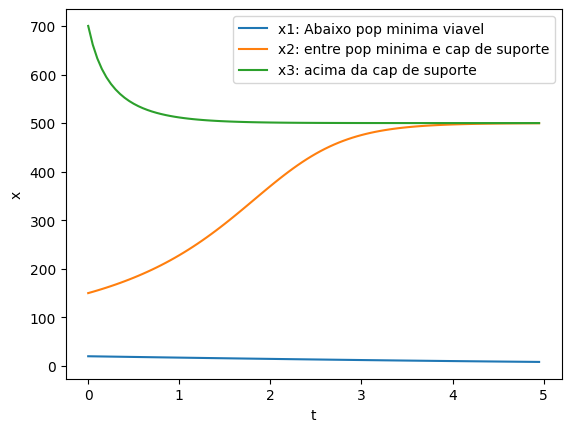

In [5]:
# Importamos as bibliotecas que vamos usar
import numpy as np
from matplotlib import pyplot as pt
from scipy.integrate import odeint

# Condicoes
t = np.arange(0, 5., 0.05)
n01 = 20
n02 = 150
n03 = 700

r = 0.25
k = 500   # capacidade maxima
a = 50    # pop minima viavel

def f(n, t, r, k, a):
  return r * n *(1 - n/k) * (n/a - 1)

x1 = odeint(f, n01, t, (r, k, a))
x2 = odeint(f, n02, t, (r, k, a))
x3 = odeint(f, n03, t, (r, k, a))

pt.plot(t, x1)
pt.plot(t, x2)
pt.plot(t, x3)
pt.xlabel('t')
pt.ylabel('x')
pt.legend(['x1: Abaixo pop minima viavel', 'x2: entre pop minima e cap de suporte', 'x3: acima da cap de suporte'], loc='best') # desenha a legenda



## Exercício 2: capacidade de suporte sazonal

Integre numericamente a equação logística, adaptando-a de tal maneira que a capacidade de suporte $K$ da população varia no tempo, de forma **periódica**.

Escolha unidades e parâmetros fixando o período de oscilação em 1 ano, e analise 2 situações:
1. $\frac{1}{r}$ muito menor que 1 ano (a população cresce numa escala de tempo muito mais rápida que a variação em K)
2. $\frac{1}{r}$ é próximo de 1 ano

Compare as soluções obtidas com a curva $K(t)$ que você escolheu, e tente explicar as diferenças entre os 2 cenários matematicamente e/ou ecologicamente.

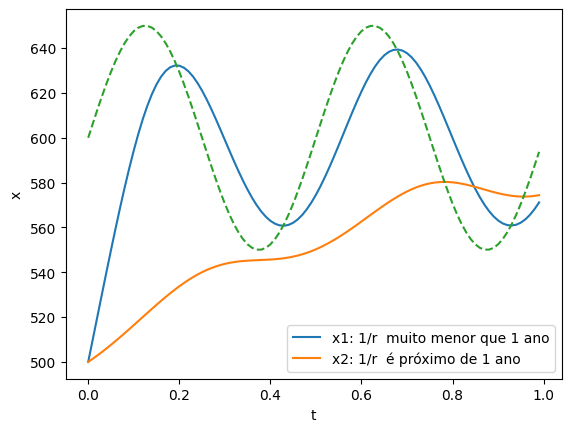

In [126]:
# Importamos as bibliotecas que vamos usar
import numpy as np
from matplotlib import pyplot as pt
from scipy.integrate import odeint

# Condicoes
t = np.arange(0, 1., 0.01)

n0 = 500
r1 = 8
r2 = 1.1
a = 200


def k(t):
    return (50 * np.sin(np.pi* 4 * t) + 600)

def f(n, t, r, a):
  return r * n *(1 - n/k(t)) * (n/a - 1)

x1 = odeint(f, n0, t, (r1, a))
x2 = odeint(f, n0, t, (r2, a))

pt.plot(t, x1)
pt.plot(t, x2)
pt.plot(t, k(t), linestyle="--")

pt.xlabel('t')
pt.ylabel('x')
pt.legend(['x1: 1/r  muito menor que 1 ano', 'x2: 1/r  é próximo de 1 ano'], loc='lower right')

Quando 1/r é muito menor que 1 ano, a população irá crescer mais rápido do que a capacidade máxima da população, isso significa que em pouco tempo a população se aproxima de sua capacidade máxima. Neste caso, a população se mostra sensível as variações da capacidade máxima, demonstrando certa instabilidade.

Por outro lado, quando 1/r for similar a 1 ano, o crescimento da população é mais lento, porém é um crescimento mais estável, sem sofrer grandes impactos quando a capacidade máxima é reduzida, significando em uma população mais adaptavel a mudanças no ambiente.

## Exercício 3: modelo de competição Lotka-Volterra

Integre numericamente as equações do modelo de competição Lotka-Volterra:

$$ \begin{aligned}
  \frac{dN_1}{dt} &= r_1 N_1 \left( \frac{K_1 - N_1 - \alpha N_2}{K_1} \right) \\
  \frac{dN_2}{dt} &= r_2 N_2 \left( \frac{K_2 - N_2 - \beta N_1}{K_2} \right)
\end{aligned} $$

Para cada caso abaixo, plote as soluções ao longo do tempo, e também a solução no espaço de fase.

**Escolha** parâmetros e condições iniciais de maneira que:
  * apenas a espécie 1 persista (independentemente de condições iniciais)
  * apenas a espécie 2 persista (independentemente de condições iniciais)
  * as 2 espécies coexistam em equilíbrio estável
  * uma persista e exclua a outra, dependendo das condições iniciais. Plote soluções correspondendo aos 2 cenários (1 exclui 2, e 2 exclui 1).



In [30]:
import numpy as np
from matplotlib import pyplot as pt
from scipy.integrate import odeint

t = np.arange(0, 50., 0.1)

# Parâmetros
r1 = 1.
r2 = 1.
k1 = 100
k2 = 100
a = 0.5
b = 0.5

# Condição inicial
n0 = np.array([50., 70.]) # n2 maior que n1]
n1 = np.array([80., 30.]) # n1 maior que n2

# Função
def LV(n, t, r1, r2, k1, k2, a, b):
    return np.array([ r1*n[0] * ((k1 - n[0] - a*n[1]) / k1),  # equação n1
                      r2*n[1] * ((k2 - n[1] - b*n[0]) / k2) ] # equação n2
                    )

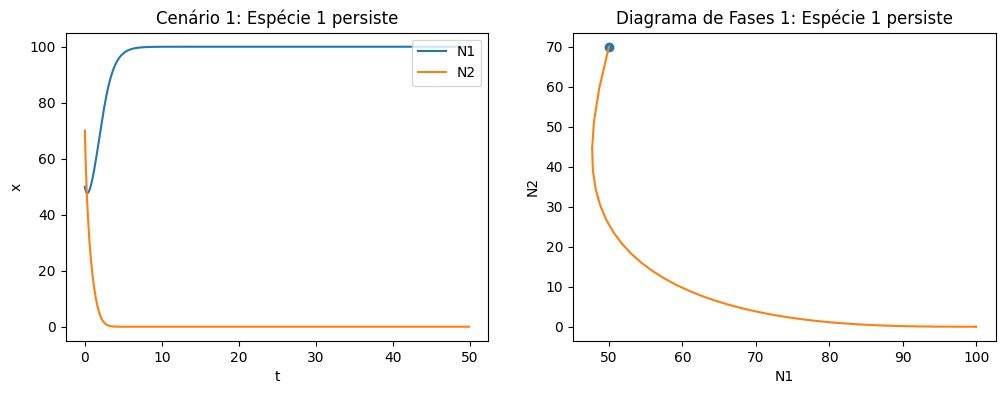

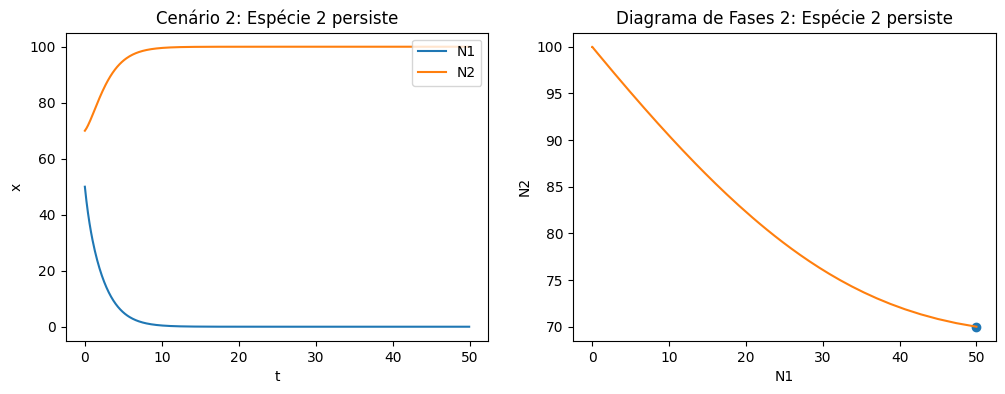

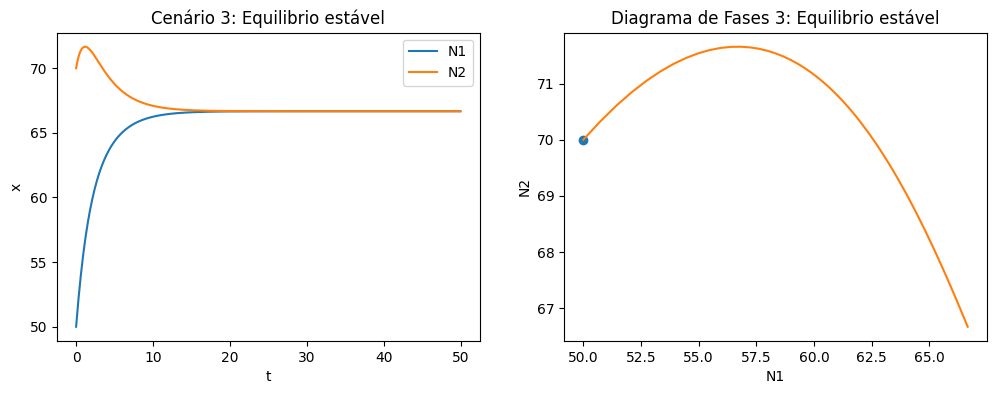

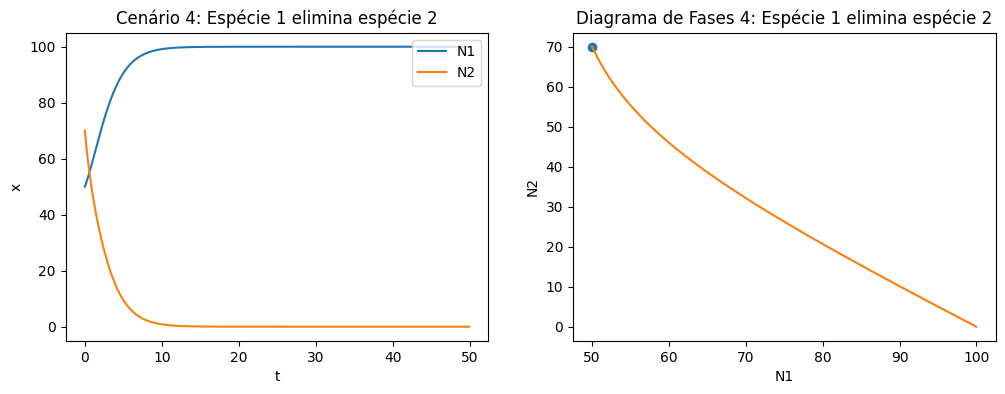

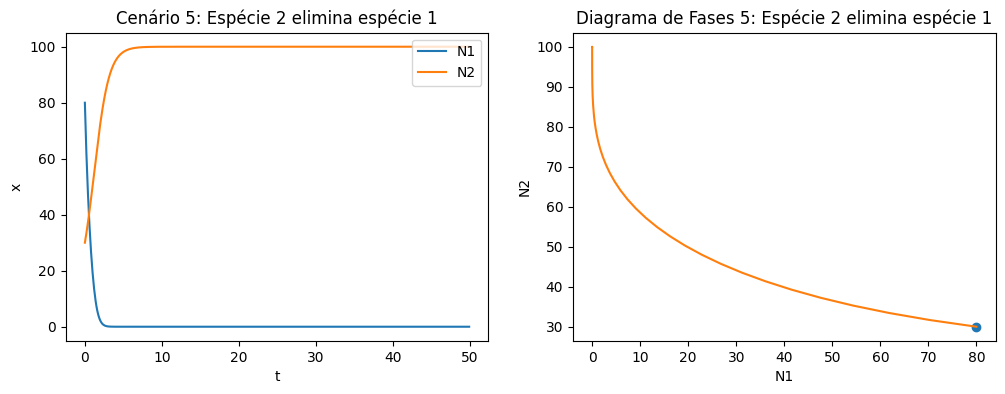

In [46]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import odeint

# Lista de valores para [condições iniciais, a, b]
lista_de_parametros = [([n0, 1.2, 4, "Espécie 1 persiste"]),
                       ([n0, 1.5, 0.5, "Espécie 2 persiste"]),
                       ([n0, 0.5, 0.5, "Equilibrio estável"]),
                       ([n0, 0.5, 1.5, "Espécie 1 elimina espécie 2"]),
                       ([n1, 5, 0.2, "Espécie 2 elimina espécie 1"]),
                       ]

# Rodando diferentes cenários, variando apenas a e b
for i, cenarios in enumerate(lista_de_parametros):
  x = odeint(LV, cenarios[0], t, (r1, r2, k1, k2, cenarios[1], cenarios[2]))

  # Ajustando os plots
  plt.figure(figsize=(12, 4))

  # Plot por Tempo
  plt.subplot(1, 2, 1)
  plt.plot(t, x)
  plt.xlabel('t')
  plt.ylabel('x')
  plt.title(f'Cenário {i+1}: {cenarios[3]}')
  pt.legend(['N1', 'N2'], loc='upper right')

  # Plot do Diagrama de Fases
  plt.subplot(1, 2, 2)
  pt.plot(x[0,0], x[0,1], 'o')
  pt.plot(x[:,0], x[:,1])
  pt.xlabel('N1')
  pt.ylabel('N2')
  plt.title(f'Diagrama de Fases {i+1}: {cenarios[3]}')

  plt.show()


### 3'. Questão extra
Existe alguma situação em que o resultado final da competição (as populações para tempo grande) dependem dos valores de $r_1$ e $r_2$? Explique.